In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [2]:
using Revise
includet("./base.jl")
includet("./plotting_extras.jl")

In [3]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

# Generating many random params to run ODEs on

In [7]:
K = 10.
l = 0.999
p = 0.01

num_systems = 100

DN = 1e-6

T = 1e8
tol = 1e-9

N = 20
M = N
ode_u0 = [fill(1., N); fill(0., M)]

rsg = get_si_sampler_for_paper(K, l, DN;
    N, M,
    DR=p,
);

metadata = (;
    K, l, p, num_systems, DN, T, tol, N, M, ode_u0, rsg,
);

In [8]:
systems = []
while length(systems) < num_systems
    gen_ps = rsg()

    ode_p = make_mmicrm_problem(gen_ps.mmicrm_params, copy(ode_u0), T)
    ode_s = solve(ode_p, TRBDF2();
        maxiters=100000,
        abstol=tol*100,
        reltol=tol,
        callback=CallbackSet(
            make_timer_callback(10),
            PositiveDomain(copy(ode_u0); save=false),
            make_ode_extinction_exit_callback(N, 1e-9)
        ),
    );
    ode_fs = ode_s.u[end]
    mresid = mmicrmmaxresid(ode_s)
    num_surv = count(>(tol * 1000), ode_fs[1:N])
    
    if (mresid < tol) && (num_surv != 0)
        push!(systems, (gen_ps, ode_fs))
        println(length(systems))
    end
end

1
2
3
4


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626


5
6
7
8
9


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626


10
11
12
13
14
15
16
17


...

74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626


93
94
95
96
97


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626


98
99
100


In [9]:
jldsave("./run_many/systems1_$num_systems.jld2"; systems, metadata)

# Playing around with a single system on my laptop

In [66]:
K = 10.
l = 1.
p = 0.01

N = 20
M = N

DN = 1e-6

rsg = get_si_sampler_for_paper(K, l, DN;
    N, M,
    DR=p,
);

In [84]:
gen_ps = rsg()

BSMMiCRMParams{Nothing, Nothing, Nothing, Float64}(BMMiCRMParams{Nothing, Float64}([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.9995945362765347, 1.0038566691265014, 0.9993866942839997, 1.0023412632706128, 1.0007982311630996, 0.9996199265231457, 1.001505000085838, 0.9986449734489398, 1.0060649479832042, 1.0006878267014203, 0.9995637246543898, 0.9995547408986384, 1.0012967172759994, 0.9971701660046487, 1.0022974267022788, 1.002730768800976, 1.0016428203485188, 0.99884109482432, 1.0004633541191499, 0.9982418810737196], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 10.0, 0.0, 0.0, 0.0, 0.0], [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], [0.0 0.0 … 0.0 0.0; 0.0 0.0 

In [85]:
T = 1e8
tol = 1e-9

ode_u0 = [fill(1., N); fill(0., M)]

ode_p = make_mmicrm_problem(gen_ps.mmicrm_params, copy(ode_u0), T)
ode_s = solve(ode_p, TRBDF2();
    maxiters=100000,
    callback=CallbackSet(make_timer_callback(10), PositiveDomain(copy(ode_u0); save=false)),
);
ode_fs = ode_s.u[end]
@show mmicrmmaxresid(ode_s) sum(ode_fs[1:N]) count(>(1e-9), ode_fs[1:N]);

mmicrmmaxresid(ode_s) = 6.03944862964544e-14
sum(ode_fs[1:N]) = 3.514988642814818
count((>)(1.0e-9), ode_fs[1:N]) = 5


In [89]:
jldsave("./run1system/sys1.jld2"; gen_ps, ode_s, ode_fs)

In [9]:
L = 5
sN = 1000
dx = L / sN
sp_epsilon = 1e-3

pde_u0 = expand_u0_to_size((sN,), ode_fs)
pde_u0 = perturb_u0_uniform(N, M, pde_u0, sp_epsilon)
clamp!(pde_u0, 0., Inf);

In [56]:
pde_ps = BSMMiCRMParams(
    gen_ps.mmicrm_params,
    gen_ps.Ds,
    CartesianSpace{1,Tuple{Periodic}}(SA[dx]),
    nthreads()
)
pde_p = make_smmicrm_problem(pde_ps, pde_u0, T; jac_type=:sparse);

pde_s_t, pde_s_u, scb = make_stepped_saver_callback(pde_u0, 10)
pde_s = solve(pde_p, TRBDF2();
    dense=false,
    abstol=tol,
    reltol=tol,
    callback=CallbackSet(make_timer_callback(15), PositiveDomain(copy(pde_u0); save=false), scb),
);
smmicrmmaxresid(pde_s)

0.0021966987058268206

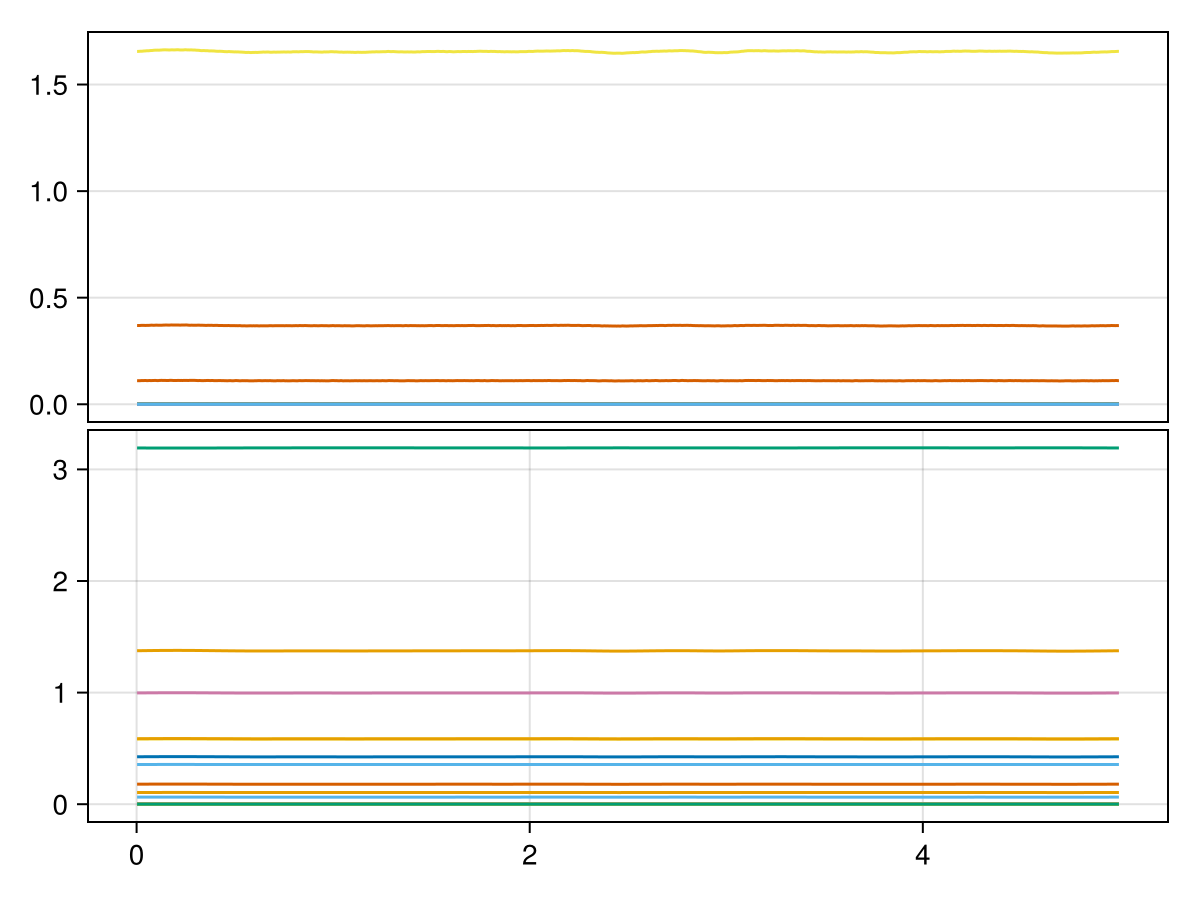

In [65]:
plot_spatial_fs(pde_s.u[end], N, sN, dx)

In [11]:
f = plot_1dsmmicrm_sol_interactive(pde_s)
display(GLMakie.Screen(), f)

GLMakie.Screen(...)

In [14]:
pde_means = map(pde_s.u) do u
    reshape(mean(u; dims=2), N+M)
end;

In [17]:
length(pde_s.t)

40027

In [25]:
jldsave("./testing_pde_s2_p0.01_increase.jld2"; pde_s)

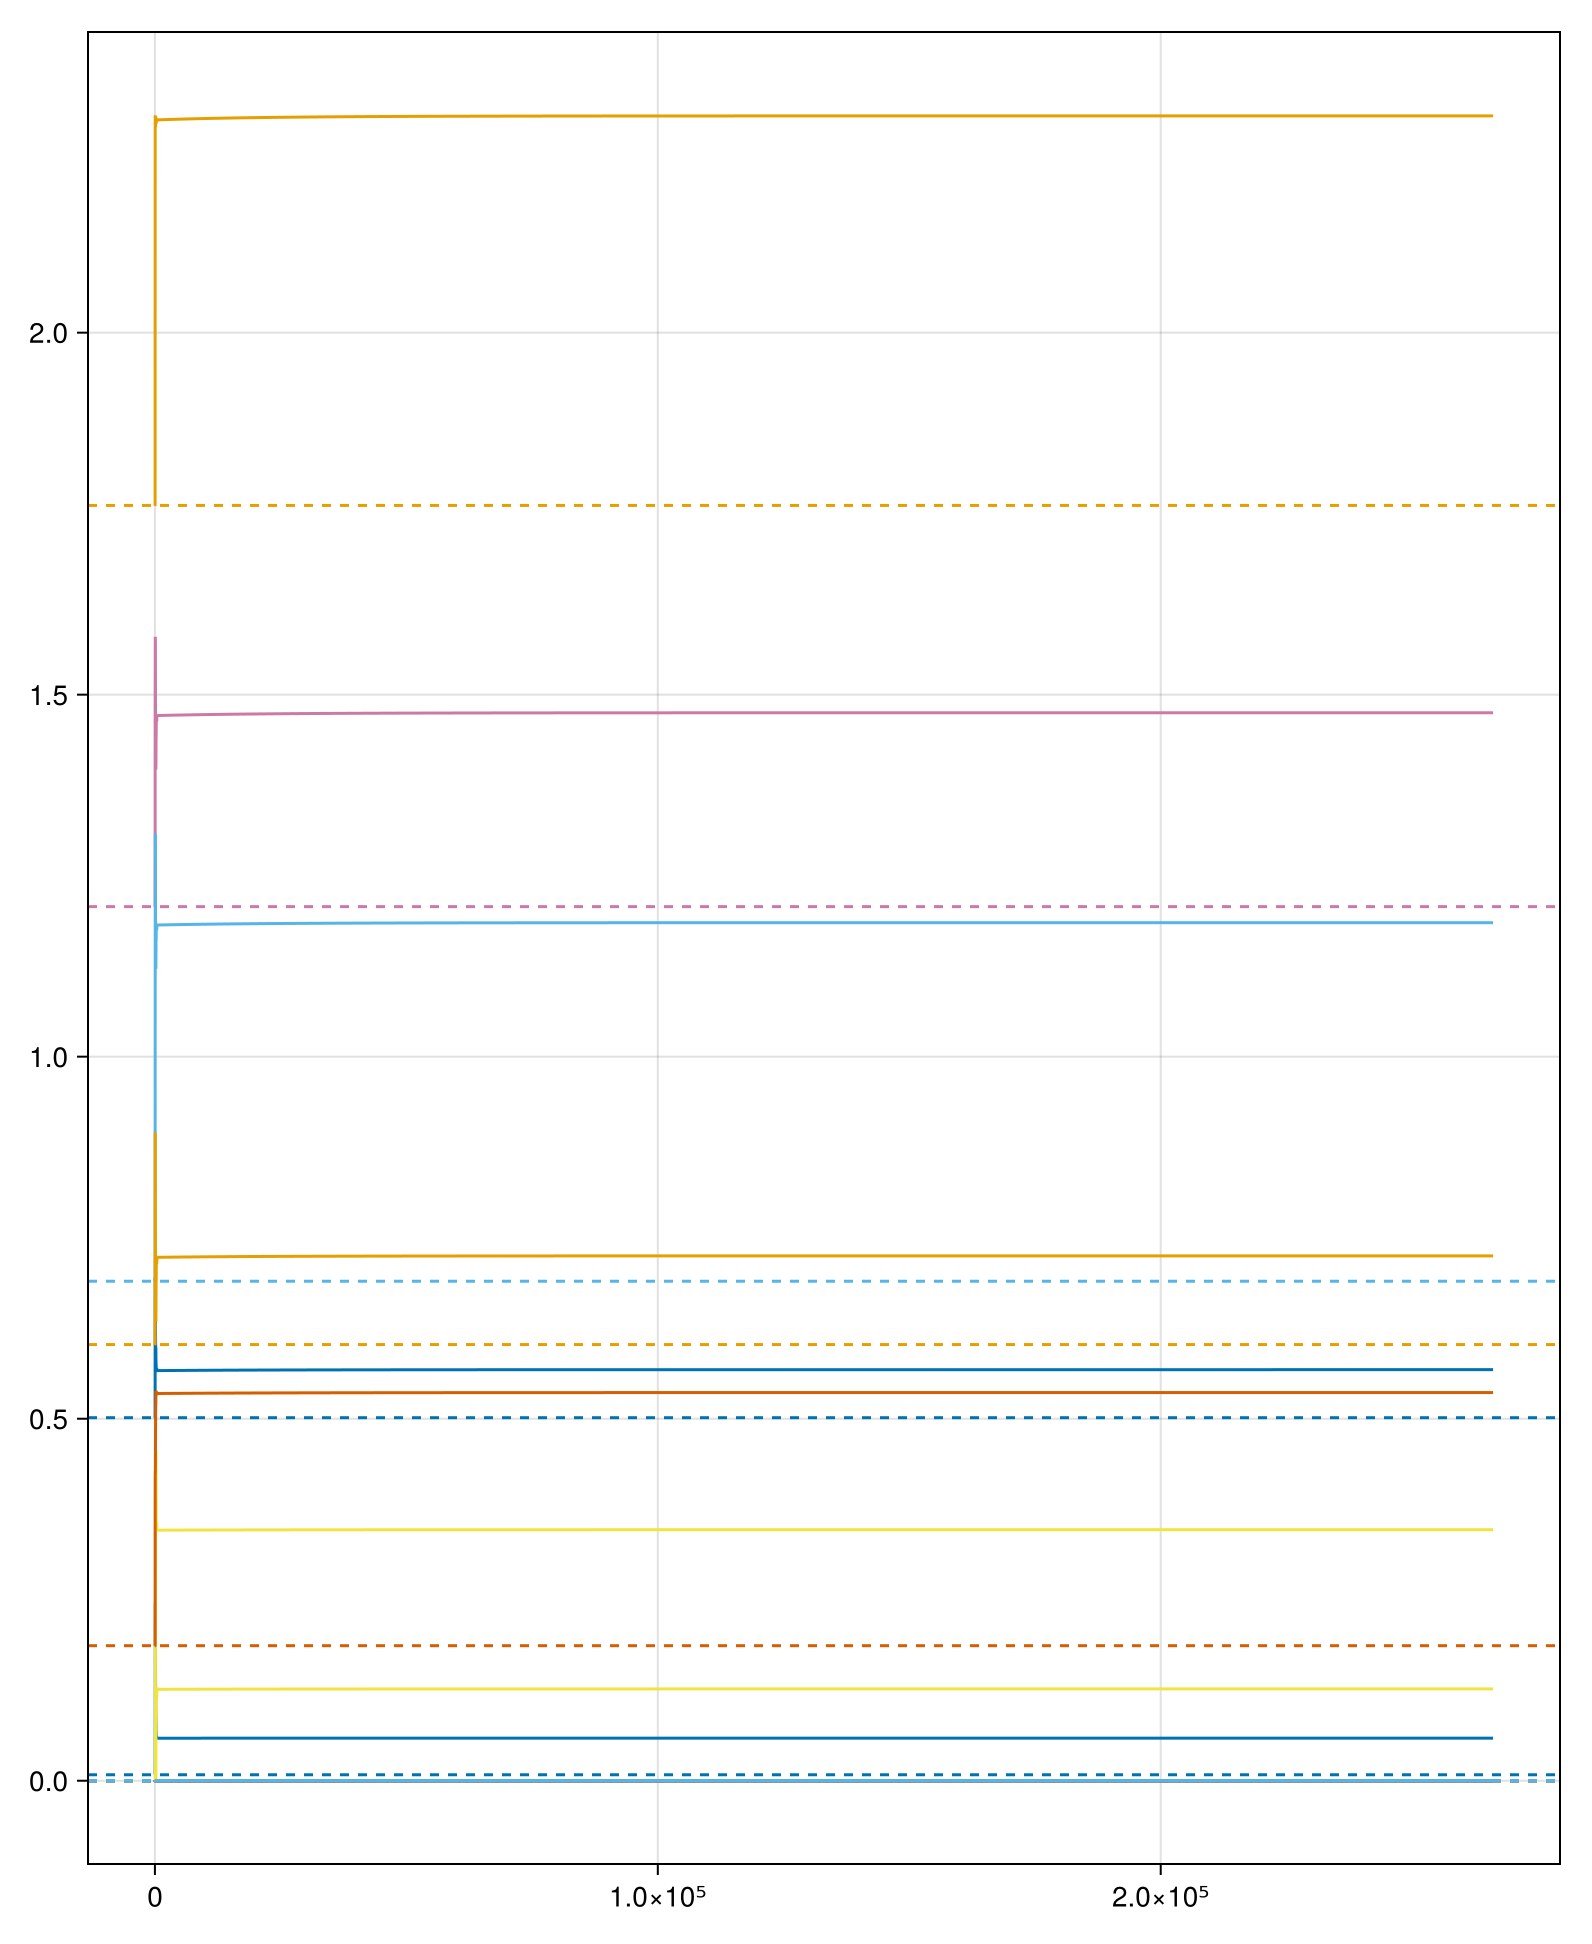

In [23]:
fig = Figure()
ax = Axis(fig[1,1])

# iis = 1:100:length(pde_s.t)
iis = 1:100:length(pde_s.t)

for i in 1:N
    lines!(ax, pde_s.t[iis], getindex.(pde_means, i)[iis])
    hlines!(ax, [ode_fs[i]];
        linestyle=:dash
    )
end

display(GLMakie.Screen(), fig)

fig